<a href="https://colab.research.google.com/github/janehannah2006/slab1/blob/main/Chest_XRay_Autoencoder_Variant_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install -q kaggle

import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cpu
CUDA available: False


In [2]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [7]:
# Download dataset directly into Colab
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:28<00:00, 86.1MB/s]



In [8]:
import os

print(os.listdir("/content"))

['.config', 'kaggle.json', 'chest-xray-pneumonia.zip', 'sample_data']


In [9]:
import zipfile

zip_path = "/content/chest-xray-pneumonia.zip"
extract_path = "/content/chest_xray"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [10]:
import os

for root, dirs, files in os.walk("/content/chest_xray"):
    if "NORMAL" in dirs or "PNEUMONIA" in dirs:
        print(root)

/content/chest_xray/chest_xray/test
/content/chest_xray/chest_xray/val
/content/chest_xray/chest_xray/__MACOSX/chest_xray/test
/content/chest_xray/chest_xray/__MACOSX/chest_xray/val
/content/chest_xray/chest_xray/__MACOSX/chest_xray/train
/content/chest_xray/chest_xray/chest_xray/test
/content/chest_xray/chest_xray/chest_xray/val
/content/chest_xray/chest_xray/chest_xray/train
/content/chest_xray/chest_xray/train


In [11]:
import zipfile
import os

zip_path = "/content/chest-xray-pneumonia.zip"
extract_path = "/content/chest_xray"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [12]:
import os

print(os.listdir("/content/chest_xray"))

['chest_xray']


In [13]:
import os

for root, dirs, files in os.walk("/content/chest_xray"):
    if "NORMAL" in dirs or "PNEUMONIA" in dirs:
        print(root)

/content/chest_xray/chest_xray/test
/content/chest_xray/chest_xray/val
/content/chest_xray/chest_xray/__MACOSX/chest_xray/test
/content/chest_xray/chest_xray/__MACOSX/chest_xray/val
/content/chest_xray/chest_xray/__MACOSX/chest_xray/train
/content/chest_xray/chest_xray/chest_xray/test
/content/chest_xray/chest_xray/chest_xray/val
/content/chest_xray/chest_xray/chest_xray/train
/content/chest_xray/chest_xray/train


In [14]:
from pathlib import Path

dataset_root = Path("/content/chest_xray/chest_xray")

classes = ["NORMAL", "PNEUMONIA"]

for split in ["train", "test", "val"]:
    print(f"\n{split.upper()}")
    for cls in classes:
        folder = dataset_root / split / cls
        count = len(list(folder.glob("*")))
        print(f"{cls}: {count}")


TRAIN
NORMAL: 1341
PNEUMONIA: 3875

TEST
NORMAL: 234
PNEUMONIA: 390

VAL
NORMAL: 8
PNEUMONIA: 8


In [15]:
from pathlib import Path

# Dataset location
dataset_root = Path("/content/chest_xray/chest_xray")

classes = ["NORMAL", "PNEUMONIA"]
splits = ["train", "test", "val"]

total = 0

for split in splits:
    print(f"\n--- {split.upper()} ---")

    for cls in classes:
        folder = dataset_root / split / cls

        if folder.exists():
            count = len([
                f for f in folder.iterdir()
                if f.suffix.lower() in [".jpeg", ".jpg", ".png"]
            ])

            print(f"{cls}: {count}")
            total += count
        else:
            print(f"{cls}: folder not found")

print("\n==========================")
print("TOTAL IMAGES:", total)
print("==========================")


--- TRAIN ---
NORMAL: 1341
PNEUMONIA: 3875

--- TEST ---
NORMAL: 234
PNEUMONIA: 390

--- VAL ---
NORMAL: 8
PNEUMONIA: 8

TOTAL IMAGES: 5856


In [16]:
from pathlib import Path

dataset_root = Path("/content/chest_xray/chest_xray")

classes = ["NORMAL", "PNEUMONIA"]

# Collect all image paths in a fixed order
all_images = []

for split in ["train", "test", "val"]:
    for cls in classes:
        folder = dataset_root / split / cls

        if folder.exists():
            images = sorted([
                f for f in folder.iterdir()
                if f.suffix.lower() in [".jpeg", ".jpg", ".png"]
            ])

            for img in images:
                all_images.append((img, cls))

print("Total images:", len(all_images))

# Variant A = first half
variant_a_size = len(all_images) // 2
variant_a = all_images[:variant_a_size]

print("Variant A images:", len(variant_a))

# Count classes in Variant A
normal_count = sum(1 for _, cls in variant_a if cls == "NORMAL")
pneumonia_count = sum(1 for _, cls in variant_a if cls == "PNEUMONIA")

print("NORMAL:", normal_count)
print("PNEUMONIA:", pneumonia_count)

Total images: 5856
Variant A images: 2928
NORMAL: 1341
PNEUMONIA: 1587


Preprocessing + Dataset


In [17]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

class ChestXRayDataset(Dataset):
    def __init__(self, image_list, transform=None):
        self.image_list = image_list
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        image_path, label = self.image_list[idx]

        image = Image.open(image_path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image, label


# Create Variant A dataset
variant_dataset = ChestXRayDataset(
    variant_a,
    transform=transform
)

# DataLoader
batch_size = 32

train_loader = DataLoader(
    variant_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

print("Variant A images:", len(variant_dataset))
print("Batch size:", batch_size)

# Check one batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("First 5 labels:", labels[:5])

Variant A images: 2928
Batch size: 32
Image batch shape: torch.Size([32, 1, 128, 128])
First 5 labels: ('PNEUMONIA', 'PNEUMONIA', 'NORMAL', 'PNEUMONIA', 'PNEUMONIA')


Build the Autoencoder


In [18]:
import torch
import torch.nn as nn

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3,
                               stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=3,
                               stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3,
                               stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=3,
                               stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


# Create model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ConvAutoencoder().to(device)

print(model)
print("\nUsing device:", device)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (7): Sigmoid()
  )
)

Using device: cpu


Train the Autoencoder

In [20]:
import torch.optim as optim

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of epochs
epochs = 3

loss_history = []

print("Training started...")

for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    for images, _ in train_loader:

        images = images.to(device)

        # Forward pass
        reconstructed = model(images)

        # Reconstruction loss
        loss = criterion(reconstructed, images)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.6f}"
    )

print("Training completed!")

Training started...
Epoch [1/3] Loss: 0.007075
Epoch [2/3] Loss: 0.002643
Epoch [3/3] Loss: 0.002217
Training completed!


Show Original vs Reconstructed X-rays


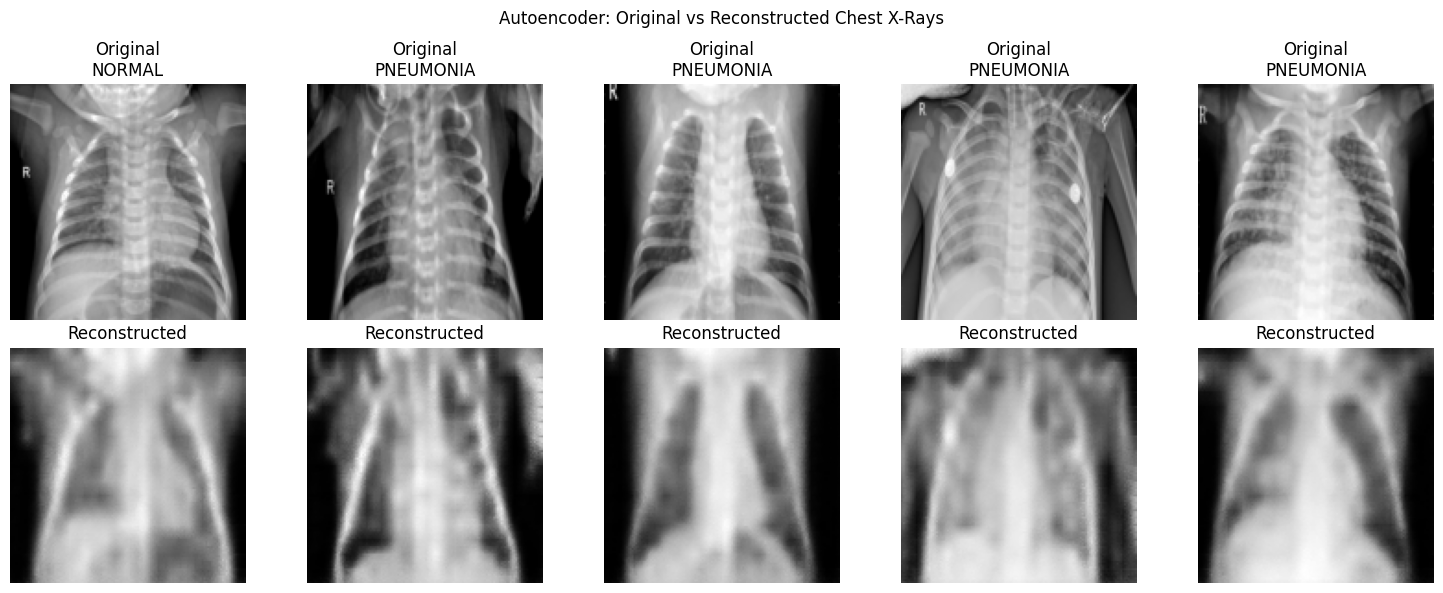

In [21]:
import matplotlib.pyplot as plt
import torch

# Put model in evaluation mode
model.eval()

# Get one batch
images, labels = next(iter(train_loader))
images = images.to(device)

# Reconstruct images
with torch.no_grad():
    reconstructed = model(images)

# Move back to CPU
images = images.cpu()
reconstructed = reconstructed.cpu()

# Display original and reconstructed images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(5):
    # Original
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].set_title(f"Original\n{labels[i]}")
    axes[0, i].axis("off")

    # Reconstructed
    axes[1, i].imshow(reconstructed[i].squeeze(), cmap="gray")
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

plt.suptitle("Autoencoder: Original vs Reconstructed Chest X-Rays")
plt.tight_layout()
plt.show()

Plot Training Loss

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(loss_history) + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Autoencoder Training Loss")
plt.xticks(range(1, len(loss_history) + 1))
plt.grid(True)

plt.show()